In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle


**This notebook contains the code used in the manuscript analysis**
**accomplished in this notebook:**
* Downloaded, cleaned, merged GUIDE-seq data collated by Yaish & Orenstein, Nucleic Acids Research, 2024 
* calculated normalized read counts
* calculated CFD for OTS with no bulges
* calculated # mismatches in the SDR

I downloaded the files processed below (FullGUIDEseq_CR_Lazzarotto_2020_dataset.csv,Tsai_2015_GUIDE_seq.csv,Chen_2017_GUIDE_seq.csv,Listgarten_2018_GUIDE_seq.csv) from the [github](https://github.com/OrensteinLab/CRISPR-Bulge/tree/main/evaluations)

In [3]:
lazzarotto_2020=pd.read_csv("../Data/YaishOrenstein2024/FullGUIDEseq_CR_Lazzarotto_2020_dataset.csv")
lazzarotto_2020

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads
0,GAAGAAACTGAGAAGCATGANGG,chr1,TGCTGCTGCTTCTCCAGCTTTCGCTCCTTCATGCTGCGCAGCTTGG...,-,15837,15860,GGCCAAGCTGCGCAGCATGAAGG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0
1,GAAGAAACTGAGAAGCATGANGG,chr1,TCTGTCACTAGGCCAGGTCTCTCAGCCCTTCTGTGCCTCAGTTTCC...,-,24130,24152,GAGGAAACTGAGGCACA-GAAGG,GAAGAAACTGAGAAGCATGANGG,4,1,0.0
2,GAAGAAACTGAGAAGCATGANGG,chr1,CTCTTCTACAACCTGTTCTATATTCCCCTCATGTTTATCCAGTGCT...,-,41251,41274,GAAGCACTGGATAAACATGAGGG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0
3,GAAGAAACTGAGAAGCATGANGG,chr1,AGAGAAATCAATGGAGGCCTGGTTACAAGGATCTAAGAAGCATCAA...,+,47678,47701,CAAGGATCTAAGAAGCATCAATG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0
4,GAAGAAACTGAGAAGCATGANGG,chr1,AGGCATCCTGGATAGTCAGGATAATCCATGCTGTATCTCAGTTTGT...,-,52897,52920,AAACAAACTGAGATACAGCATGG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
3271044,GTTTGCGACTCTGACAGAGCNGG,chrY,TATACCGAATGGATAGGCCTATGGATCGGCTCTTTCAAAGTTGTAA...,-,25438794,25438817,GATTACAACTTTGAAAGAGCCGA,GTTTGCGACTCTGACAGAGCNGG,6,0,0.0
3271045,GTTTGCGACTCTGACAGAGCNGG,chrY,AAAAGGAGATTAGGAAATGAGGGAAGCAGCGCTGTCAGAGTTTCCA...,-,25475441,25475464,TTTGGAAACTCTGACAGCGCTGC,GTTTGCGACTCTGACAGAGCNGG,6,0,0.0
3271046,GTTTGCGACTCTGACAGAGCNGG,chrY,ACTCCTGGCTTCAAGTACTCTGCCTGTTTTGGCCTCTAAAAGTGCC...,+,25579286,25579309,GTTTTGGCCTCTAAAAGTGCCGG,GTTTGCGACTCTGACAGAGCNGG,6,0,0.0
3271047,GTTTGCGACTCTGACAGAGCNGG,chrY,TTTAAAACGTTAGACCTTCAGTGGTCCTCCTCCTTCAGCCTCCCAA...,-,25692093,25692116,GTTTGGGAGGCTGAAGGAGGAGG,GTTTGCGACTCTGACAGAGCNGG,6,0,0.0


This is the same length as the previous, so I need to manually concatenate with the independent datasets (also provided in their github) 

In [4]:
tsai_2015=pd.read_csv("../Data/YaishOrenstein2024/Tsai_2015_GUIDE_seq.csv")
tsai_2015

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads
0,GAACACAAAGCATAGACTGCNGG,chr10,TGTTATTCAGCCTGCTTGGGAGTACTTTGCAGTCTATGCTTTATGT...,-,85365602,85365625,AAACATAAAGCATAGACTGCAAA,GAACACAAAGCATAGACTGCNGG,4,0,4.0
1,GAACACAAAGCATAGACTGCNGG,chr4,CAGAGTGTGGAGAGTGAGTAAGCCAGAACACAATGCATAGATTGCC...,+,89601015,89601038,GAACACAATGCATAGATTGCCGG,GAACACAAAGCATAGACTGCNGG,2,0,102.0
2,GAACACAAAGCATAGACTGCNGG,chr5,CCCGCTGGCCCTGTAAAGGAAACTGGAACACAAAGCATAGACTGCG...,+,87944779,87944802,GAACACAAAGCATAGACTGCGGG,GAACACAAAGCATAGACTGCNGG,0,0,1681.0
3,GACCCCCTCCACCCCGCCTCNGG,chr1,CTGCCCCTTCCCCCGGGTCGGCCCTGACCCTGTCCACCCCACCTCA...,+,939940,939963,GACCCTGTCCACCCCACCTCAGG,GACCCCCTCCACCCCGCCTCNGG,3,0,136.0
4,GACCCCCTCCACCCCGCCTCNGG,chr1,TGAAGGGTTGGGACTGTTGGGTGAGTGGCCCCTCCGCCCCACCTCT...,+,1358876,1358898,G-GCCCCTCCGCCCCACCTCTGG,GACCCCCTCCACCCCGCCTCNGG,3,1,19.0
...,...,...,...,...,...,...,...,...,...,...,...
1935204,GGAATCCCTTCTGCAGCACCNGG,chrY,TTGGACACCTTATACCCACAGTCCTCCAGGTGCTGAAGCAGGGCAT...,-,57160513,57160536,GGATGCCCTGCTTCAGCACCTGG,GGAATCCCTTCTGCAGCACCNGG,4,0,0.0
1935205,GGAATCCCTTCTGCAGCACCNGG,chrY,TGGACACCTTATACCCACAGTCCTCCAGGTGCTGAAGCAGGGCATC...,-,57160513,57160537,CGGATGCCCTGCTTCAGCACCTGG,GGAAT-CCCTTCTGCAGCACCNGG,4,1,0.0
1935206,GGAATCCCTTCTGCAGCACCNGG,chrY,CCTTGGCCTCGGCCCCAAGTGGTGTCCCGGAGATGCAGCAGCGTCT...,-,57203205,57203228,GGAGACGCTGCTGCATCTCCGGG,GGAATCCCTTCTGCAGCACCNGG,6,0,0.0
1935207,GGAATCCCTTCTGCAGCACCNGG,chrY,CCGTCGTCTTCTGCAGCTCTGGAGACCTGATGCTGGGGAAGGGCAT...,-,57213924,57213947,GCATGCCCTTCCCCAGCATCAGG,GGAATCCCTTCTGCAGCACCNGG,6,0,0.0


In [5]:
chen_2017=pd.read_csv("../Data/YaishOrenstein2024/Chen_2017_GUIDE_seq.csv")
chen_2017

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads
0,GACCCCCTCCACCCCGCCTCNGG,chr1,CTGCCCCTTCCCCCGGGTCGGCCCTGACCCTGTCCACCCCACCTCA...,+,939940,939963,GACCCTGTCCACCCCACCTCAGG,GACCCCCTCCACCCCGCCTCNGG,3,0,258.0
1,GACCCCCTCCACCCCGCCTCNGG,chr1,TGAAGGGTTGGGACTGTTGGGTGAGTGGCCCCTCCGCCCCACCTCT...,+,1358876,1358898,G-GCCCCTCCGCCCCACCTCTGG,GACCCCCTCCACCCCGCCTCNGG,3,1,33.0
2,GACCCCCTCCACCCCGCCTCNGG,chr1,TCTTTTTCTCAGGCAAGACAAGCTTCCCCCCTCCACCCCCGCCCCC...,+,51752230,51752254,TCCCCCCTCCACCCCCGCCCCCGG,GACCCCCTCCA-CCCCGCCTCNGG,3,1,171.0
3,GACCCCCTCCACCCCGCCTCNGG,chr1,GCATCTCTGCAGCCCAGGACACCCGCCTCCCCCACACCCCGCATCC...,+,151059391,151059415,GCCTCCCCCACACCCCGCATCCGG,GAC-CCCCTCCACCCCGCCTCNGG,4,1,521.0
4,GACCCCCTCCACCCCGCCTCNGG,chr1,CCCGCCCAGCCCCGGGCTTTGTCCGCCTGGGGCGGGGTGGGCAGGG...,-,9689817,9689840,GACCCTGCCCACCCCGCCCCAGG,GACCCCCTCCACCCCGCCTCNGG,4,0,19.0
...,...,...,...,...,...,...,...,...,...,...,...
1741643,GACCCCCTCCACCCCGCCTCNGG,chrY,TCCAGAGTTCACAGACCTCACTTCTGATCTCCACCACCCCTCCTCC...,+,56871080,56871103,GATCTCCACCACCCCTCCTCCCC,GACCCCCTCCACCCCGCCTCNGG,6,0,0.0
1741644,GACCCCCTCCACCCCGCCTCNGG,chrY,CTATTGGGTACACCTCCCAGACGGGGCGGCTGCTGGGCGGAGGGGC...,-,57094325,57094348,GAGCCCCTCCGCCCAGCAGCCGC,GACCCCCTCCACCCCGCCTCNGG,6,0,0.0
1741645,GACCCCCTCCACCCCGCCTCNGG,chrY,AGGGGCTCCTCACTTCGCAGACGGGGCGGCTGCCGGGTGGAGGGTC...,-,57094365,57094388,GAGACCCTCCACCCGGCAGCCGC,GACCCCCTCCACCCCGCCTCNGG,6,0,0.0
1741646,GACCCCCTCCACCCCGCCTCNGG,chrY,GTACTTGCCTCCAGCTGGCCTTTCAGACCCCATCCCTCCTGCCTCC...,+,57186012,57186035,GACCCCATCCCTCCTGCCTCCTG,GACCCCCTCCACCCCGCCTCNGG,5,0,0.0


In [6]:
listgarten_2018=pd.read_csv("../Data/YaishOrenstein2024/Listgarten_2018_GUIDE_seq.csv")
listgarten_2018

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads
0,GAAAAAGTACACGCCTACAGNGG,chr11,TGTCCTCAGGGTGAGTGGAGGAGGGGAAAAAGTACACGCCTACAGT...,+,58203359,58203382,GAAAAAGTACACGCCTACAGTGG,GAAAAAGTACACGCCTACAGNGG,0,0,493.0
1,GAAAAAGTACACGCCTACAGNGG,chr11,ACAGTTGTATTACTGTTCTACGGAACCATTGTAGGCGTGTACTTTT...,-,58215543,58215566,GAAAAAGTACACGCCTACAATGG,GAAAAAGTACACGCCTACAGNGG,1,0,165.0
2,GACCACGTAGGGCGACTGCCNGG,chr3,TTCCACTGCTCCTGGTGCTGGCACACCTGGCAGTCGCCCTACGTGG...,-,187199576,187199599,GACCACGTAGGGCGACTGCCAGG,GACCACGTAGGGCGACTGCCNGG,0,0,1689.0
3,GACTCAGAACCGCTTAAATCNGG,chr22,ATAATCAACTTTTAGAAATTCAAGAGACTCAGAACCGCTTAAATCT...,+,32453427,32453450,GACTCAGAACCGCTTAAATCTGG,GACTCAGAACCGCTTAAATCNGG,0,0,1235.0
4,GAGGGTTGCGTTCCTTGAGCNGG,chr11,TGCTCTCCAACCCCCACGATCTGTCCCTGCTCAAGGAACGCAACCC...,-,104037295,104037318,GAGGGTTGCGTTCCTTGAGCAGG,GAGGGTTGCGTTCCTTGAGCNGG,0,0,2764.0
...,...,...,...,...,...,...,...,...,...,...,...
579090,GTCCCTTCGCCAGCTGTTAGNGG,chrY,TTTCCATGGCAGAACTGTGTTTCCCGTTCCTTTGCTTCCTGTTAGG...,+,26170181,26170204,GTTCCTTTGCTTCCTGTTAGGGG,GTCCCTTCGCCAGCTGTTAGNGG,5,0,0.0
579091,GTCCCTTCGCCAGCTGTTAGNGG,chrY,CATGAGAAAATAGTACCATAAACTAATACCTGCTCCATCTCTTAGA...,+,26277774,26277797,ATACCTGCTCCATCTCTTAGAGG,GTCCCTTCGCCAGCTGTTAGNGG,6,0,0.0
579092,GTCCCTTCGCCAGCTGTTAGNGG,chrY,GCGCACAGAAGACCTCAGGCTCAGGTTCCACTCCCCAGCTGTGAAA...,+,26409227,26409250,TTCCACTCCCCAGCTGTGAAAGG,GTCCCTTCGCCAGCTGTTAGNGG,6,0,0.0
579093,GTCCCTTCGCCAGCTGTTAGNGG,chrY,TTCACTACAGACTGACGATAGACAGTTCCTTGACCAGCTGCTTTGA...,+,26614068,26614092,GTTCCTTGACCAGCTGCTTTGAGG,GTCCCTTCGCCAGCTG-TTAGNGG,4,1,0.0


In [7]:
guideseq=pd.concat([lazzarotto_2020,tsai_2015,chen_2017,listgarten_2018], keys=["lazzarotto_2020","tsai_2015","chen_2017","listgarten_2018"]).reset_index()
guideseq["dataset"]=guideseq["level_0"]
guideseq=guideseq.drop(["level_0","level_1"],axis=1)
guideseq

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads,dataset
0,GAAGAAACTGAGAAGCATGANGG,chr1,TGCTGCTGCTTCTCCAGCTTTCGCTCCTTCATGCTGCGCAGCTTGG...,-,15837,15860,GGCCAAGCTGCGCAGCATGAAGG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0,lazzarotto_2020
1,GAAGAAACTGAGAAGCATGANGG,chr1,TCTGTCACTAGGCCAGGTCTCTCAGCCCTTCTGTGCCTCAGTTTCC...,-,24130,24152,GAGGAAACTGAGGCACA-GAAGG,GAAGAAACTGAGAAGCATGANGG,4,1,0.0,lazzarotto_2020
2,GAAGAAACTGAGAAGCATGANGG,chr1,CTCTTCTACAACCTGTTCTATATTCCCCTCATGTTTATCCAGTGCT...,-,41251,41274,GAAGCACTGGATAAACATGAGGG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0,lazzarotto_2020
3,GAAGAAACTGAGAAGCATGANGG,chr1,AGAGAAATCAATGGAGGCCTGGTTACAAGGATCTAAGAAGCATCAA...,+,47678,47701,CAAGGATCTAAGAAGCATCAATG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0,lazzarotto_2020
4,GAAGAAACTGAGAAGCATGANGG,chr1,AGGCATCCTGGATAGTCAGGATAATCCATGCTGTATCTCAGTTTGT...,-,52897,52920,AAACAAACTGAGATACAGCATGG,GAAGAAACTGAGAAGCATGANGG,6,0,0.0,lazzarotto_2020
...,...,...,...,...,...,...,...,...,...,...,...,...
7526996,GTCCCTTCGCCAGCTGTTAGNGG,chrY,TTTCCATGGCAGAACTGTGTTTCCCGTTCCTTTGCTTCCTGTTAGG...,+,26170181,26170204,GTTCCTTTGCTTCCTGTTAGGGG,GTCCCTTCGCCAGCTGTTAGNGG,5,0,0.0,listgarten_2018
7526997,GTCCCTTCGCCAGCTGTTAGNGG,chrY,CATGAGAAAATAGTACCATAAACTAATACCTGCTCCATCTCTTAGA...,+,26277774,26277797,ATACCTGCTCCATCTCTTAGAGG,GTCCCTTCGCCAGCTGTTAGNGG,6,0,0.0,listgarten_2018
7526998,GTCCCTTCGCCAGCTGTTAGNGG,chrY,GCGCACAGAAGACCTCAGGCTCAGGTTCCACTCCCCAGCTGTGAAA...,+,26409227,26409250,TTCCACTCCCCAGCTGTGAAAGG,GTCCCTTCGCCAGCTGTTAGNGG,6,0,0.0,listgarten_2018
7526999,GTCCCTTCGCCAGCTGTTAGNGG,chrY,TTCACTACAGACTGACGATAGACAGTTCCTTGACCAGCTGCTTTGA...,+,26614068,26614092,GTTCCTTGACCAGCTGCTTTGAGG,GTCCCTTCGCCAGCTG-TTAGNGG,4,1,0.0,listgarten_2018


### Normalizing reads

Normalizing to expression of the target site. For repeat sgRNAs, normalize to expression of the sgRNA from the same dataset. 

In [8]:
guideseq["reads"]=guideseq["reads"].astype(np.float64)
guideseq["sgRNA_and_dataset"]=guideseq["sgRNA"]+guideseq["dataset"]
target_site= guideseq[(guideseq["Align.#Mismatches"]==0)&(guideseq["Align.#Bulges"]==0)].reset_index(drop=True).copy()


In [9]:
target_site

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads,dataset,sgRNA_and_dataset
0,GAAGAAACTGAGAAGCATGANGG,chr2,ACTGACAGGTGCAGCCTGTACTTGTCCGTCATGCTTCTCAGTTTCT...,-,136115707,136115730,GAAGAAACTGAGAAGCATGACGG,GAAGAAACTGAGAAGCATGANGG,0,0,11671.0,lazzarotto_2020,GAAGAAACTGAGAAGCATGANGGlazzarotto_2020
1,GAAGATGATGGAGTAGATGGNGG,chr2,ATCCATTGCCCACAATGCCAGTTAAGAAGATGATGGAGTAGATGGT...,+,136115780,136115803,GAAGATGATGGAGTAGATGGTGG,GAAGATGATGGAGTAGATGGNGG,0,0,16554.0,lazzarotto_2020,GAAGATGATGGAGTAGATGGNGGlazzarotto_2020
2,GAAGCATGACGGACAAGTACNGG,chr2,GGAGGTCGGCCACTGACAGGTGCAGCCTGTACTTGTCCGTCATGCT...,-,136115696,136115719,GAAGCATGACGGACAAGTACAGG,GAAGCATGACGGACAAGTACNGG,0,0,15644.0,lazzarotto_2020,GAAGCATGACGGACAAGTACNGGlazzarotto_2020
3,GAAGCGTGATGACAAAGAGGNGG,chr2,GCCACGGCATCAACTGCCCAGAAGGGAAGCGTGATGACAAAGAGGA...,+,136115653,136115676,GAAGCGTGATGACAAAGAGGAGG,GAAGCGTGATGACAAAGAGGNGG,0,0,52202.0,lazzarotto_2020,GAAGCGTGATGACAAAGAGGNGGlazzarotto_2020
4,GAAGGCTGAGATCCTGGAGGNGG,chr12,CCCAGCTCCCCTGCAGCCCCACAATCCCCCTCCAGGATCTCAGCCT...,-,6773276,6773299,GAAGGCTGAGATCCTGGAGGGGG,GAAGGCTGAGATCCTGGAGGNGG,0,0,81217.0,lazzarotto_2020,GAAGGCTGAGATCCTGGAGGNGGlazzarotto_2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,GGTGGCATCTGCTTATTTCANGG,chr7,ACTCCAATTAGCAGTAAGTGAAAATCCTTGAAATAAGCAGATGCCA...,-,123171882,123171905,GGTGGCATCTGCTTATTTCAAGG,GGTGGCATCTGCTTATTTCANGG,0,0,1518.0,listgarten_2018,GGTGGCATCTGCTTATTTCANGGlistgarten_2018
113,GTCCCTTCGCCAGCTGTTAGNGG,chr17,ATCCCATGCAGGCTGCTGATGTCAGCCTCTAACAGCTGGCGAAGGG...,-,40982425,40982448,GTCCCTTCGCCAGCTGTTAGAGG,GTCCCTTCGCCAGCTGTTAGNGG,0,0,1154.0,listgarten_2018,GTCCCTTCGCCAGCTGTTAGNGGlistgarten_2018
114,GTTCTTCTGATCAGGTTGAANGG,chr3,TGAGTGGACAGACACTTTGATGGCCGTTCTTCTGATCAGGTTGAAA...,+,38792073,38792096,GTTCTTCTGATCAGGTTGAAAGG,GTTCTTCTGATCAGGTTGAANGG,0,0,1586.0,listgarten_2018,GTTCTTCTGATCAGGTTGAANGGlistgarten_2018
115,GTTTCATCGTGCTCAAGAACNGG,chr10,ACATGTTGGTGACAGTATGCATGTGCCGGTTCTTGAGCACGATGAA...,-,70266182,70266205,GTTTCATCGTGCTCAAGAACCGG,GTTTCATCGTGCTCAAGAACNGG,0,0,2298.0,listgarten_2018,GTTTCATCGTGCTCAAGAACNGGlistgarten_2018


In [10]:
guideseq=guideseq.merge(target_site[["sgRNA_and_dataset","reads"]],how="left",on="sgRNA_and_dataset",suffixes=("","_ontarget"))


Text(0.5, 1.0, 'Distribution of nonzero normalized reads')

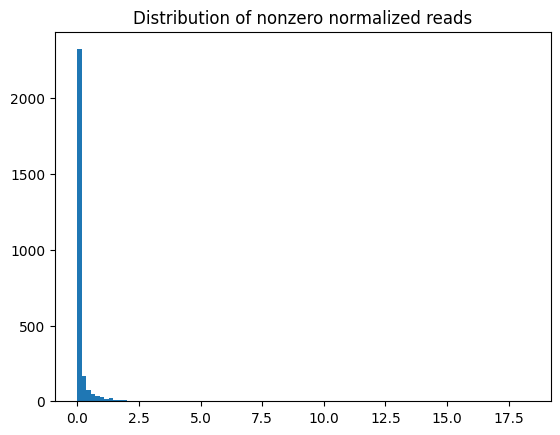

In [11]:
#normalized reads to # of on-target reads for each sgRNA
guideseq.loc[:,"normalized_reads"]= (guideseq["reads"]/guideseq["reads_ontarget"])
#remove on-target sites
guideseq=guideseq[(guideseq['Align.#Mismatches']!=0) | (guideseq['Align.#Bulges']!=0)].reset_index(drop=True).copy()
guideseq[guideseq["reads"]>0]["normalized_reads"].hist(grid=False,bins=100)
plt.title("Distribution of nonzero normalized reads")


**Note on repeating data** 

The paper states that "each off-target site can be uniquely identified by the quartet (sgRNA, chromosome,strand, and genome end position)".

The paper also states that they "expanded the set of GUIDE-seq datasets to cover 117 sgRNAs, with a combined total
of 2,877 identified OTS, including 591 OTS with bulges." (this refers to the number of *active* sites).

However, with we need to verify that this count agrees with the number of unique guides and off-target sites.

In [12]:
guideseq["unique_identifier"]=guideseq["sgRNA"]+"_"+guideseq["chrom"].astype(str)+"_"+guideseq["Align.strand"].astype(str)+"_"+guideseq["Align.chromEnd"].astype(str)
OTS_counts=pd.DataFrame(guideseq["unique_identifier"].value_counts())
num_repeated_OTS=len(OTS_counts[OTS_counts["count"]>1])
print("# of repeated OTS:", num_repeated_OTS)


# of repeated OTS: 1669496


Repeats exist due to the fact that the same sgRNAs are included across datasets, and thus they share off-target sites. This is known because there are 0 repeats when dataset is added to the unique identifier:

In [13]:
guideseq["unique_identifier_withdataset"]=guideseq["sgRNA"]+"_"+guideseq["chrom"].astype(str)+"_"+guideseq["Align.strand"].astype(str)+"_"+guideseq["Align.chromEnd"].astype(str)+guideseq["dataset"]
OTS_counts=pd.DataFrame(guideseq["unique_identifier_withdataset"].value_counts())
print("# of repeated OTS:", len(OTS_counts[OTS_counts["count"]>1]))


# of repeated OTS: 0


In [14]:
#example
guideseq[guideseq["unique_identifier"]=="GGTGAGTGAGTGTGTGCGTGNGG_chr12_+_20526928"][["unique_identifier","dataset"]]

,unique_identifier,dataset
3670927,GGTGAGTGAGTGTGTGCGTGNGG_chr12_+_20526928,tsai_2015
5604534,GGTGAGTGAGTGTGTGCGTGNGG_chr12_+_20526928,chen_2017


I am taking the average of GUIDE-seq reads (normalized to the number of reads of the guide target site in the respective experiment) of sites for guides repeated across datasets 

In [16]:
guideseq_norepeats = (guideseq.groupby(["sgRNA","chrom","Align.strand","Align.chromStart","unique_identifier","Align.#Mismatches","Align.#Bulges","Align.off-target","SiteWindow"])
            .agg(normalized_reads= ("normalized_reads","mean")
                )
            .reset_index())
guideseq_norepeats 

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads
0,GAAAAAGTACACGCCTACAGNGG,chr1,+,60782,GAAAAAGTACACGCCTACAGNGG_chr1_+_60805,6,0,AAAAAAATACATGCATATTGTGG,CCATGCACAAATTCACTGAGAGTTTAAAAAAATACATGCATATTGT...,0.0
1,GAAAAAGTACACGCCTACAGNGG,chr1,+,82787,GAAAAAGTACACGCCTACAGNGG_chr1_+_82809,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0
2,GAAAAAGTACACGCCTACAGNGG,chr1,+,416866,GAAAAAGTACACGCCTACAGNGG_chr1_+_416888,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0
3,GAAAAAGTACACGCCTACAGNGG,chr1,+,652613,GAAAAAGTACACGCCTACAGNGG_chr1_+_652635,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0
4,GAAAAAGTACACGCCTACAGNGG,chr1,+,878336,GAAAAAGTACACGCCTACAGNGG_chr1_+_878360,3,1,GAAAAAGCACACGACATGCAGAGG,AGTGGATCAGGTACATTATAAACTGAAAAAGCACACGACATGCAGA...,0.0
...,...,...,...,...,...,...,...,...,...,...
5857383,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26375673,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26375696,6,0,CTTTTATAACCAGTTCTAATTGG,TAAATGGGAAAAAGAATTGGAAGTCCCAATTAGAACTGGTTATAAA...,0.0
5857384,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870613,4,1,TGTTA-CAACCAGTTCAAAAGGG,AATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAA...,0.0
5857385,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870614,5,0,ATGTTACAACCAGTTCAAAAGGG,ATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAAC...,0.0
5857386,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870615,4,1,GATGTTACAACCAGTTCAAAAGGG,TAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAACA...,0.0


In [17]:
#confirms this way of collapsing data removed all repeats, nothing else
(len(guideseq)-len(guideseq_norepeats))==num_repeated_OTS

True

There is further repetition within the data. 

The paper's definition of a "unique" off-target site refers to the site end position (since this is variable for bulge vs. mismatch sites), yet there should only be one off-target site at each start position as well. This is because GUIDE-seq is not sufficiently precise to be able to distinguish whether a sgRNA binds at a bulge or with mismatches at OTS where both are possible.

Looking at repeat start position, we see numerous off-target sites for the same guides at the same position. 



In [18]:
guideseq_norepeats["chrom_sgRNA_Align.chromStart"]=guideseq_norepeats["chrom"]+guideseq_norepeats["sgRNA"]+guideseq_norepeats["Align.chromStart"].astype(str)+guideseq["Align.strand"].astype(str)
guideseq_norepeats["chrom_sgRNA_Align.chromStart"].value_counts()

chrom_sgRNA_Align.chromStart
chr10GGTGAGTGAGTGTGTGCGTGNGG48259626-     3
chr18GGTGAGTGAGTGTGTGCGTGNGG32378038+     3
chr18GGTGAGTGAGTGTGTGCGTGNGG32882807+     3
chr1GGGAAAGACCCAGCATCCGTNGG52857698-      3
chr18GGTGAGTGAGTGTGTGCGTGNGG32829631+     3
                                         ..
chr12GCTGCAGAAGGGATTCCATGNGG128990492+    1
chr12GCTGCAGAAGGGATTCCATGNGG128936062-    1
chr12GCTGCAGAAGGGATTCCATGNGG128677455+    1
chr12GCTGCAGAAGGGATTCCATGNGG128664236+    1
chrYGTTTGGCAACCAGTTCCAAANGG56882651+      1
Name: count, Length: 5128698, dtype: int64

However, there are no instances in which repeated off-target sites are active

In [19]:
guideseq_norepeats[guideseq_norepeats["normalized_reads"]>0.01]["chrom_sgRNA_Align.chromStart"].value_counts()

chrom_sgRNA_Align.chromStart
chr11GAAAAAGTACACGCCTACAGNGG58215543-    1
chr7GGAGAAGGTGGGGGGGTTCCNGG151198897-    1
chr2GGAGTGAGGGAAACGGCCCCNGG113165264-    1
chr18GGAGTGAGGGAAACGGCCCCNGG48006711+    1
chr11GGAGTGAGGGAAACGGCCCCNGG61788406+    1
                                        ..
chr2GAGCAGGGCTGGGGAGAAGGNGG217402337+    1
chr2GAGCAGGGCTGGGGAGAAGGNGG172084655+    1
chr2GAGCAGGGCTGGGGAGAAGGNGG113226922+    1
chr2GAGCAGGGCTGGGGAGAAGGNGG63613328-     1
chr8GTTGGAGAAGCTGCAGGTGANGG102784592-    1
Name: count, Length: 1350, dtype: int64

These repeats will therefore not impact the total count of active off-target sites

In [20]:
#unique sgRNAs
print("# guides:",len(guideseq_norepeats["sgRNA"].unique()))
print("# OTS:",len(guideseq_norepeats))
print("total normalized reads:",guideseq_norepeats["normalized_reads"].sum())
# number of "active OTS" (norm reads >0.01 )
active_ots=guideseq_norepeats[guideseq_norepeats["normalized_reads"]>=0.01].reset_index(drop=True).copy()
print("total # active OTS:", len(active_ots))
print("avg normalized reads among active ots:",active_ots["normalized_reads"].sum()/len(active_ots))


# guides: 114
# OTS: 5857388
total normalized reads: 348.7681653408535
total # active OTS: 1350
avg normalized reads among active ots: 0.2556065099824046


In [21]:
#exporting file that contains all collated data with repeats removed and counts normalized to the on-target site 
#guideseq_norepeats.to_csv("../Data/guideseq_2024_processed.csv",index=False)

# For off-target sites with no bulges

The number of mismatches in the SDR and CFD score are only relevant for off-target sites with no bulges

In [22]:
guideseq_nobulges=guideseq_norepeats[guideseq_norepeats["Align.#Bulges"]==0].reset_index(drop=True).copy()
#get rid of ots with N in sequence
guideseq_nobulges=guideseq_nobulges[guideseq_nobulges["Align.off-target"].str.count("N")==0].reset_index(drop=True).copy()
guideseq_nobulges

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart
0,GAAAAAGTACACGCCTACAGNGG,chr1,+,60782,GAAAAAGTACACGCCTACAGNGG_chr1_+_60805,6,0,AAAAAAATACATGCATATTGTGG,CCATGCACAAATTCACTGAGAGTTTAAAAAAATACATGCATATTGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG60782-
1,GAAAAAGTACACGCCTACAGNGG,chr1,+,1147757,GAAAAAGTACACGCCTACAGNGG_chr1_+_1147780,6,0,GAAAAAGCACAGGCCGGGCGCGG,TCATATTGTTTGGGGCTCTCCTTAAGAAAAAGCACAGGCCGGGCGC...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1147757+
2,GAAAAAGTACACGCCTACAGNGG,chr1,+,1879103,GAAAAAGTACACGCCTACAGNGG_chr1_+_1879126,6,0,GAAAAGGCACAATCCTACAGTAC,CAAATCTCTGAGTTCTCCTCCCCAGGAAAAGGCACAATCCTACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1879103-
3,GAAAAAGTACACGCCTACAGNGG,chr1,+,2238701,GAAAAAGTACACGCCTACAGNGG_chr1_+_2238724,6,0,GAAGGTGTACACGTCCACTGAGG,CTGTGGACACTGCGTGTGTGGTGCTGAAGGTGTACACGTCCACTGA...,0.0,chr1GAAAAAGTACACGCCTACAGNGG2238701-
4,GAAAAAGTACACGCCTACAGNGG,chr1,+,2354551,GAAAAAGTACACGCCTACAGNGG_chr1_+_2354574,6,0,AAGAAAGTAGAAGCCTACGGGAG,ACTGCACTCCAGCCTGGGTGACAGAAAGAAAGTAGAAGCCTACGGG...,0.0,chr1GAAAAAGTACACGCCTACAGNGG2354551+
...,...,...,...,...,...,...,...,...,...,...,...
3722614,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26172873,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26172896,6,0,GCTGTGCAGCCAGTTCCTAACAG,ACTCATTCAGGTACCAGTGCATGATCTGTTAGGAACTGGCTGCACA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26172873+
3722615,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26363046,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26363069,6,0,GTCTTGCAGCAAGTTCCCCATGG,AAATTATACAGCTGTCCCTCAGCATCCATGGGGAACTTGCTGCAAG...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26363046+
3722616,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26375673,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26375696,6,0,CTTTTATAACCAGTTCTAATTGG,TAAATGGGAAAAAGAATTGGAAGTCCCAATTAGAACTGGTTATAAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26375673+
3722617,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870614,5,0,ATGTTACAACCAGTTCAAAAGGG,ATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAAC...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG56870591+


### Calculating # mismatches in SDR

Counting the number of mismatches in guide positions 3-20 + the PAM ("Specificity-defining region", aka SDR)


In [23]:
guideseq_nobulges["sgrna_countwindow"]=guideseq_nobulges["sgRNA"].str[3:23]
guideseq_nobulges["offtarget_countwindow"]=guideseq_nobulges["Align.off-target"].str[3:23]


In [24]:
#function to determine count of mismatches between on-target and off-target site
#inputs: sgRNA (not index) positions 4-20 of off-target and on-target site (so that mismatches in sgRNA positions 1-3 do not towards total)
def mismatch_counter(offtarg,ontarg):
    #end case 
    #when checking last position of two sequences, return 0 if nucleotides match, 1 if not
    if len(offtarg)==1:
        return int(offtarg[0]!=ontarg[0])          

    #recursive case 
    #add 1 to the mismatch count if first position of off-target and off-target string are different
    if offtarg[0]!=ontarg[0]:
        return 1+ mismatch_counter(offtarg[1:],ontarg[1:])
    else:
        return mismatch_counter(offtarg[1:],ontarg[1:])


In [25]:
#apply function to calculating # mismatches in SDR  
guideseq_nobulges["mismatches_in_SDR"]=guideseq_nobulges.apply(lambda x: mismatch_counter(x['offtarget_countwindow'], x['sgrna_countwindow']), axis=1)
#subtract 1 since "N" of sgRNA PAM will never match the OTS 
guideseq_nobulges["mismatches_in_SDR"]=guideseq_nobulges["mismatches_in_SDR"]-1
guideseq_nobulges


,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart,sgrna_countwindow,offtarget_countwindow,mismatches_in_SDR
0,GAAAAAGTACACGCCTACAGNGG,chr1,+,60782,GAAAAAGTACACGCCTACAGNGG_chr1_+_60805,6,0,AAAAAAATACATGCATATTGTGG,CCATGCACAAATTCACTGAGAGTTTAAAAAAATACATGCATATTGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG60782-,AAAGTACACGCCTACAGNGG,AAAATACATGCATATTGTGG,5
1,GAAAAAGTACACGCCTACAGNGG,chr1,+,1147757,GAAAAAGTACACGCCTACAGNGG_chr1_+_1147780,6,0,GAAAAAGCACAGGCCGGGCGCGG,TCATATTGTTTGGGGCTCTCCTTAAGAAAAAGCACAGGCCGGGCGC...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1147757+,AAAGTACACGCCTACAGNGG,AAAGCACAGGCCGGGCGCGG,6
2,GAAAAAGTACACGCCTACAGNGG,chr1,+,1879103,GAAAAAGTACACGCCTACAGNGG_chr1_+_1879126,6,0,GAAAAGGCACAATCCTACAGTAC,CAAATCTCTGAGTTCTCCTCCCCAGGAAAAGGCACAATCCTACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1879103-,AAAGTACACGCCTACAGNGG,AAGGCACAATCCTACAGTAC,6
3,GAAAAAGTACACGCCTACAGNGG,chr1,+,2238701,GAAAAAGTACACGCCTACAGNGG_chr1_+_2238724,6,0,GAAGGTGTACACGTCCACTGAGG,CTGTGGACACTGCGTGTGTGGTGCTGAAGGTGTACACGTCCACTGA...,0.0,chr1GAAAAAGTACACGCCTACAGNGG2238701-,AAAGTACACGCCTACAGNGG,GGTGTACACGTCCACTGAGG,6
4,GAAAAAGTACACGCCTACAGNGG,chr1,+,2354551,GAAAAAGTACACGCCTACAGNGG_chr1_+_2354574,6,0,AAGAAAGTAGAAGCCTACGGGAG,ACTGCACTCCAGCCTGGGTGACAGAAAGAAAGTAGAAGCCTACGGG...,0.0,chr1GAAAAAGTACACGCCTACAGNGG2354551+,AAAGTACACGCCTACAGNGG,AAAGTAGAAGCCTACGGGAG,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3722614,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26172873,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26172896,6,0,GCTGTGCAGCCAGTTCCTAACAG,ACTCATTCAGGTACCAGTGCATGATCTGTTAGGAACTGGCTGCACA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26172873+,TGGCAACCAGTTCCAAANGG,GTGCAGCCAGTTCCTAACAG,5
3722615,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26363046,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26363069,6,0,GTCTTGCAGCAAGTTCCCCATGG,AAATTATACAGCTGTCCCTCAGCATCCATGGGGAACTTGCTGCAAG...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26363046+,TGGCAACCAGTTCCAAANGG,TTGCAGCAAGTTCCCCATGG,5
3722616,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26375673,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26375696,6,0,CTTTTATAACCAGTTCTAATTGG,TAAATGGGAAAAAGAATTGGAAGTCCCAATTAGAACTGGTTATAAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26375673+,TGGCAACCAGTTCCAAANGG,TTATAACCAGTTCTAATTGG,5
3722617,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870614,5,0,ATGTTACAACCAGTTCAAAAGGG,ATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAAC...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG56870591+,TGGCAACCAGTTCCAAANGG,TTACAACCAGTTCAAAAGGG,3


### Acquiring CFD score 

Adapting prior GPP code (cfd-score-calculator.py) to calculate CFD score form Cas9 CFD and PAM matrices.


In [26]:
#Reverse complements a given string
def revcom(s):
    basecomp = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A','U':'A'}
    letters = list(s[::-1])
    letters = [basecomp[base] for base in letters]
    return ''.join(letters)

#Unpickle mismatch scores and PAM scores
def get_mm_pam_scores():
    mm_scores = pickle.load(open('../Data/CFD_Scoring/mismatch_score.pkl','rb'))
    pam_scores = pickle.load(open('../Data/CFD_Scoring/pam_scores.pkl','rb'))
    return (mm_scores,pam_scores)


#Calculates CFD score. 
def calc_cfd(wt,off):
    if(len(off)<20):
        print("ots<20")
    pam = off[-2:]
    sg = off[:-3]
    sg = sg.replace('T','U')
    wt = wt.replace('T','U')
    mm_scores,pam_scores = get_mm_pam_scores()
    s_list = list(sg)
    wt_list = list(wt)
    score = 1
    for i,sl in enumerate(s_list):
        if wt_list[i] == sl:
            score*=1
        else:
            key = 'r'+wt_list[i]+':d'+revcom(sl)+','+str(i+1)
            score*= mm_scores[key]
    score*=pam_scores[pam]
    return (score)


In [27]:
#THIS TAKES A LONG TIME TO RUN
guideseq_nobulges['cfd_score'] = guideseq_nobulges.apply(lambda x: calc_cfd(x["sgRNA"], x["Align.off-target"]), axis=1)
guideseq_nobulges

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart,sgrna_countwindow,offtarget_countwindow,mismatches_in_SDR,cfd_score
0,GAAAAAGTACACGCCTACAGNGG,chr1,+,60782,GAAAAAGTACACGCCTACAGNGG_chr1_+_60805,6,0,AAAAAAATACATGCATATTGTGG,CCATGCACAAATTCACTGAGAGTTTAAAAAAATACATGCATATTGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG60782-,AAAGTACACGCCTACAGNGG,AAAATACATGCATATTGTGG,5,0.037278
1,GAAAAAGTACACGCCTACAGNGG,chr1,+,1147757,GAAAAAGTACACGCCTACAGNGG_chr1_+_1147780,6,0,GAAAAAGCACAGGCCGGGCGCGG,TCATATTGTTTGGGGCTCTCCTTAAGAAAAAGCACAGGCCGGGCGC...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1147757+,AAAGTACACGCCTACAGNGG,AAAGCACAGGCCGGGCGCGG,6,0.000749
2,GAAAAAGTACACGCCTACAGNGG,chr1,+,1879103,GAAAAAGTACACGCCTACAGNGG_chr1_+_1879126,6,0,GAAAAGGCACAATCCTACAGTAC,CAAATCTCTGAGTTCTCCTCCCCAGGAAAAGGCACAATCCTACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1879103-,AAAGTACACGCCTACAGNGG,AAGGCACAATCCTACAGTAC,6,0.000000
3,GAAAAAGTACACGCCTACAGNGG,chr1,+,2238701,GAAAAAGTACACGCCTACAGNGG_chr1_+_2238724,6,0,GAAGGTGTACACGTCCACTGAGG,CTGTGGACACTGCGTGTGTGGTGCTGAAGGTGTACACGTCCACTGA...,0.0,chr1GAAAAAGTACACGCCTACAGNGG2238701-,AAAGTACACGCCTACAGNGG,GGTGTACACGTCCACTGAGG,6,0.084615
4,GAAAAAGTACACGCCTACAGNGG,chr1,+,2354551,GAAAAAGTACACGCCTACAGNGG_chr1_+_2354574,6,0,AAGAAAGTAGAAGCCTACGGGAG,ACTGCACTCCAGCCTGGGTGACAGAAAGAAAGTAGAAGCCTACGGG...,0.0,chr1GAAAAAGTACACGCCTACAGNGG2354551+,AAAGTACACGCCTACAGNGG,AAAGTAGAAGCCTACGGGAG,4,0.014853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3722614,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26172873,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26172896,6,0,GCTGTGCAGCCAGTTCCTAACAG,ACTCATTCAGGTACCAGTGCATGATCTGTTAGGAACTGGCTGCACA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26172873+,TGGCAACCAGTTCCAAANGG,GTGCAGCCAGTTCCTAACAG,5,0.013889
3722615,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26363046,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26363069,6,0,GTCTTGCAGCAAGTTCCCCATGG,AAATTATACAGCTGTCCCTCAGCATCCATGGGGAACTTGCTGCAAG...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26363046+,TGGCAACCAGTTCCAAANGG,TTGCAGCAAGTTCCCCATGG,5,0.002533
3722616,GTTTGGCAACCAGTTCCAAANGG,chrY,-,26375673,GTTTGGCAACCAGTTCCAAANGG_chrY_-_26375696,6,0,CTTTTATAACCAGTTCTAATTGG,TAAATGGGAAAAAGAATTGGAAGTCCCAATTAGAACTGGTTATAAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG26375673+,TGGCAACCAGTTCCAAANGG,TTATAACCAGTTCTAATTGG,5,0.048750
3722617,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870614,5,0,ATGTTACAACCAGTTCAAAAGGG,ATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAAC...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG56870591+,TGGCAACCAGTTCCAAANGG,TTACAACCAGTTCAAAAGGG,3,0.063000


In [28]:
#only keep relevant columns 
guideseq_nobulges=guideseq_nobulges[["sgRNA","Align.off-target",'Align.#Mismatches','normalized_reads','mismatches_in_SDR','cfd_score']]
guideseq_nobulges.to_csv("../Data/guideseq_2024_nobulges_withCFD.csv",index=False)


## For off-target sites with bulges

After removing repeats, some bulge off-target sites remain that could bind with a direct mismatch

Remove these by discarding any "bulge" off-target sites that can bind directly somewhere in the sitewindow with 3 or fewer mismatches in the SDR. 

Rationale: the exact position is imprecise, so reads could be associated with any activity in the site window:
"Additionally, for each sgRNA, we excluded potential OTS found within a genome window surrounding the experimentally identified sites for that particular sgRNA. This approach is not only based on the assumption that neighboring sites may be considered the same, especially when considering bulges, but also takes into account the fact that current state-of-the-art experimental techniques, such as CHANGE-seq and GUIDE-seq (15; 30), cannot precisely determine the exact position of an off-target site within a sequencing read. Similar to the GUIDE-seq pipeline, we defined the genome window as the identified off-target site plus an additional 25 flanking positions. We consider all potential OTS that satisfy the search thresholds in a window as inactive OTS. When multiple optimal alignments exist for the same target site, SWOffinder outputs the alignment with fewer bulges."


In [29]:
'''
    performs a sliding window along the site window to see the minimum # mismatches between the SDR 
    of the guide and the site window.
    purpose: OTS should not count as a bulge if it can bind in site window with few mismatches.
    Remember to subtract 1 from the count of mismatches afterwards (because of the N in the PAM)
'''
def min_mismatch_counter(sgRNA,sitewindow,strand):
    #specificity-defining region of guide is positions 4-20 + PAM
    SDR=sgRNA[3:]
    if strand =="-":
        sitewindow=revcom(sitewindow)
    #SiteWindow is 73 nucleotides long (20 for target + 3 for PAM + 25 flanking on each site)
    #SDR length is 20, so there are (73-20+1=) 54 different positions along the site window the SDR can bind  
    num_sliding_windows=54
    min_mm=20 #placeholder: maximum possible # mismatches
    for i in range(num_sliding_windows):
        mm=mismatch_counter(sitewindow[i:i+20],SDR)
        if mm<min_mm:
            min_mm=mm
    #subtract 1 from final mismatch count to exclude the N in the PAM 
    min_mm=min_mm-1
    return min_mm 

In [30]:
guideseq_bulges=guideseq_norepeats[guideseq_norepeats["Align.#Bulges"]>0].reset_index(drop=True).copy()
guideseq_bulges

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart
0,GAAAAAGTACACGCCTACAGNGG,chr1,+,82787,GAAAAAGTACACGCCTACAGNGG_chr1_+_82809,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG82787-
1,GAAAAAGTACACGCCTACAGNGG,chr1,+,416866,GAAAAAGTACACGCCTACAGNGG_chr1_+_416888,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG416866-
2,GAAAAAGTACACGCCTACAGNGG,chr1,+,652613,GAAAAAGTACACGCCTACAGNGG_chr1_+_652635,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG652613+
3,GAAAAAGTACACGCCTACAGNGG,chr1,+,878336,GAAAAAGTACACGCCTACAGNGG_chr1_+_878360,3,1,GAAAAAGCACACGACATGCAGAGG,AGTGGATCAGGTACATTATAAACTGAAAAAGCACACGACATGCAGA...,0.0,chr1GAAAAAGTACACGCCTACAGNGG878336-
4,GAAAAAGTACACGCCTACAGNGG,chr1,+,1138059,GAAAAAGTACACGCCTACAGNGG_chr1_+_1138081,4,1,GAGGGAGTTCACGCCT-CAGGGG,TTCAGGCTCACGTCCTGTGTGGCCTGGAGGGAGTTCACGCCTCAGG...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1138059-
...,...,...,...,...,...,...,...,...,...,...,...
2134757,GTTTGGCAACCAGTTCCAAANGG,chrY,-,21616790,GTTTGGCAACCAGTTCCAAANGG_chrY_-_21616814,4,1,GATTGTCAAGCCAGTTCCATATTG,TTGAGTTTGTCTGTAATACCCAAGCAATATGGAACTGGCTTGACAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG21616790+
2134758,GTTTGGCAACCAGTTCCAAANGG,chrY,-,22099262,GTTTGGCAACCAGTTCCAAANGG_chrY_-_22099284,4,1,CTTTGGCAAA-AGTTACAAAAAG,GGACTTGTCACTAGGCAATGGTGACCCTTTTTGTAACTTTTGCCAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG22099262+
2134759,GTTTGGCAACCAGTTCCAAANGG,chrY,-,24198928,GTTTGGCAACCAGTTCCAAANGG_chrY_-_24198950,4,1,CTTTGGGAACCA-TTGAAAAAGG,GATATGATATCTAGTACGTCTAAGTACCTTTTTCAATGGTTCCCAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG24198928+
2134760,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870613,4,1,TGTTA-CAACCAGTTCAAAAGGG,AATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG56870591+


In [31]:
print("dropping OTS that have an N in the site window, which have a sum of ",guideseq_bulges[guideseq_bulges["SiteWindow"].str.count("N")>0]["normalized_reads"].sum(), "normalized reads")
guideseq_bulges=guideseq_bulges[guideseq_bulges["SiteWindow"].str.count("N")==0].reset_index(drop=True).copy()

dropping OTS that have an N in the site window, which have a sum of  0.0 normalized reads


In [32]:
guideseq_bulges["min_mismatches"]=guideseq_bulges.apply(lambda x: min_mismatch_counter(x['sgRNA'], x['SiteWindow'],x['Align.strand']), axis=1)
guideseq_bulges

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart,min_mismatches
0,GAAAAAGTACACGCCTACAGNGG,chr1,+,82787,GAAAAAGTACACGCCTACAGNGG_chr1_+_82809,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG82787-,8
1,GAAAAAGTACACGCCTACAGNGG,chr1,+,416866,GAAAAAGTACACGCCTACAGNGG_chr1_+_416888,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG416866-,8
2,GAAAAAGTACACGCCTACAGNGG,chr1,+,652613,GAAAAAGTACACGCCTACAGNGG_chr1_+_652635,4,1,TAAAAACTACA-TCCCACAGTGG,CCAGTTTACAAAAGTTACTAAACAAATAAAAACTACATCCCACAGT...,0.0,chr1GAAAAAGTACACGCCTACAGNGG652613+,8
3,GAAAAAGTACACGCCTACAGNGG,chr1,+,878336,GAAAAAGTACACGCCTACAGNGG_chr1_+_878360,3,1,GAAAAAGCACACGACATGCAGAGG,AGTGGATCAGGTACATTATAAACTGAAAAAGCACACGACATGCAGA...,0.0,chr1GAAAAAGTACACGCCTACAGNGG878336-,8
4,GAAAAAGTACACGCCTACAGNGG,chr1,+,1138059,GAAAAAGTACACGCCTACAGNGG_chr1_+_1138081,4,1,GAGGGAGTTCACGCCT-CAGGGG,TTCAGGCTCACGTCCTGTGTGGCCTGGAGGGAGTTCACGCCTCAGG...,0.0,chr1GAAAAAGTACACGCCTACAGNGG1138059-,7
...,...,...,...,...,...,...,...,...,...,...,...,...
2134694,GTTTGGCAACCAGTTCCAAANGG,chrY,-,21616790,GTTTGGCAACCAGTTCCAAANGG_chrY_-_21616814,4,1,GATTGTCAAGCCAGTTCCATATTG,TTGAGTTTGTCTGTAATACCCAAGCAATATGGAACTGGCTTGACAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG21616790+,7
2134695,GTTTGGCAACCAGTTCCAAANGG,chrY,-,22099262,GTTTGGCAACCAGTTCCAAANGG_chrY_-_22099284,4,1,CTTTGGCAAA-AGTTACAAAAAG,GGACTTGTCACTAGGCAATGGTGACCCTTTTTGTAACTTTTGCCAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG22099262+,6
2134696,GTTTGGCAACCAGTTCCAAANGG,chrY,-,24198928,GTTTGGCAACCAGTTCCAAANGG_chrY_-_24198950,4,1,CTTTGGGAACCA-TTGAAAAAGG,GATATGATATCTAGTACGTCTAAGTACCTTTTTCAATGGTTCCCAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG24198928+,6
2134697,GTTTGGCAACCAGTTCCAAANGG,chrY,-,56870591,GTTTGGCAACCAGTTCCAAANGG_chrY_-_56870613,4,1,TGTTA-CAACCAGTTCAAAAGGG,AATAGATGTGTCCGTCCCTTTGGGTTCCCTTTTGAACTGGTTGTAA...,0.0,chrYGTTTGGCAACCAGTTCCAAANGG56870591+,3


This count reveals the off-target sites reported as bulges that are actually sites where the guide is likely binding directly. While this is a small portion of the bulge OTS, this includes those with high read counts.

In [33]:
#example: guides reported as bulge sites but would have 0 mm in SDR from direct binding in the site window. These have a large number of reads. 
guideseq_bulges[guideseq_bulges["min_mismatches"]==0]

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart,min_mismatches
202884,GACCCCCTCCACCCCGCCTCNGG,chr5,+,6714989,GACCCCCTCCACCCCGCCTCNGG_chr5_+_6715011,1,1,TA-CCCCTCCACCCCGCCTCCGG,GAGATTGGAACGGGAAATCGACTCTCTACCCCTCCACCCCGCCTCC...,4.014607,chr5GACCCCCTCCACCCCGCCTCNGG6714989-,0
306308,GAGCAGGGCTGGGGAGAAGGNGG,chr6,+,160124679,GAGCAGGGCTGGGGAGAAGGNGG_chr6_+_160124701,1,1,G-TCAGGGCTGGGGAGAAGGAGG,GACAAGATGTAAGAGATGCCAGCATTGTCAGGGCTGGGGAGAAGGA...,0.741794,chr6GAGCAGGGCTGGGGAGAAGGNGG160124679-,0


In [34]:
guideseq_bulges_filt=guideseq_bulges[guideseq_bulges["min_mismatches"]>=3].sort_values(by="normalized_reads",ascending=False).reset_index(drop=True).copy()
guideseq_bulges_filt

,sgRNA,chrom,Align.strand,Align.chromStart,unique_identifier,Align.#Mismatches,Align.#Bulges,Align.off-target,SiteWindow,normalized_reads,chrom_sgRNA_Align.chromStart,min_mismatches
0,GACCCCCTCCACCCCGCCTCNGG,chr1,+,151059391,GACCCCCTCCACCCCGCCTCNGG_chr1_+_151059415,4,1,GCCTCCCCCACACCCCGCATCCGG,GCATCTCTGCAGCCCAGGACACCCGCCTCCCCCACACCCCGCATCC...,0.931182,chr1GACCCCCTCCACCCCGCCTCNGG151059391+,3
1,GGGGGTTCCAGGGCCTGTCTNGG,chr3,-,134146156,GGGGGTTCCAGGGCCTGTCTNGG_chr3_-_134146180,1,1,GGGGGATCCAAGGGCCTGTCTGGG,TGCCATTCTTGCCCACTGTGATGACCCAGACAGGCCCTTGGATCCC...,0.834133,chr3GGGGGTTCCAGGGCCTGTCTNGG134146156+,3
2,GAGCAGGGCTGGGGAGAAGGNGG,chr6,-,100945509,GAGCAGGGCTGGGGAGAAGGNGG_chr6_-_100945533,1,1,CAGCAGGGCTGAGGGAGAAGGAGG,GAACCATCAGCTACCTTACCACCTCCTCCTTCTCCCTCAGCCCTGC...,0.575492,chr6GAGCAGGGCTGGGGAGAAGGNGG100945509-,6
3,GAGCAGGGCTGGGGAGAAGGNGG,chr1,+,176043137,GAGCAGGGCTGGGGAGAAGGNGG_chr1_+_176043159,3,1,AAG-AGGGCCAGGGAGAAGGAGG,TTCTGCCGATGAAAGGAATTACAGTTAAGAGGGCCAGGGAGAAGGA...,0.468271,chr1GAGCAGGGCTGGGGAGAAGGNGG176043137-,3
4,GACCCCCTCCACCCCGCCTCNGG,chr3,-,31417159,GACCCCCTCCACCCCGCCTCNGG_chr3_-_31417181,4,1,TTCCCCCAC-ACCCCGCCCCAGG,TTTCCACCCTATTCCCAAGAGATGATCCTGGGGCGGGGTGTGGGGG...,0.438102,chr3GACCCCCTCCACCCCGCCTCNGG31417159-,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2121570,GCTTCCGTTGCTTAGCTCTGNGG,chr1,+,15392895,GCTTCCGTTGCTTAGCTCTGNGG_chr1_+_15392917,4,1,CCTACCG-TGCTAAGCACTGGGG,ACTTACTGAGGACCTAGGCTAGGCCACCTACCGTGCTAAGCACTGG...,0.000000,chr1GCTTCCGTTGCTTAGCTCTGNGG15392895+,5
2121571,GCTTCCGTTGCTTAGCTCTGNGG,chr1,+,13974042,GCTTCCGTTGCTTAGCTCTGNGG_chr1_+_13974066,4,1,GCTTCCAGGAGCTTCGCTCAGGGG,AAGTCTGGTGGAAACCAGGCACAAGCTTCCAGGAGCTTCGCTCAGG...,0.000000,chr1GCTTCCGTTGCTTAGCTCTGNGG13974042+,6
2121572,GCTTCCGTTGCTTAGCTCTGNGG,chr1,+,12691298,GCTTCCGTTGCTTAGCTCTGNGG_chr1_+_12691320,4,1,TTTTCCGATGCTT-GCTCAGAGG,TGGTAGAGGCAGGCATGGAAGCCACGTTTTCCGATGCTTGCTCAGA...,0.000000,chr1GCTTCCGTTGCTTAGCTCTGNGG12691298-,8
2121573,GCTTCCGTTGCTTAGCTCTGNGG,chr1,+,11316514,GCTTCCGTTGCTTAGCTCTGNGG_chr1_+_11316538,4,1,GCTCCCCTCTGCTTTGCTCTGCAG,CCTGGACAGGGGTCCTCTCAGGTGGCTCCCCTCTGCTTTGCTCTGC...,0.000000,chr1GCTTCCGTTGCTTAGCTCTGNGG11316514+,5


We do see some examples of guides that seem to be a true bulge off-target site. For example, this site proposes a DNA bulge in the middle, and has more than 50% of the reads of the on-target site. As reported in row 1 of the dataset above, there is no site within this window for which the guide could bind directly with fewer than 6 mismatches. 

In [35]:
guideseq[guideseq["unique_identifier"]=="GAGCAGGGCTGGGGAGAAGGNGG_chr6_-_100945533"]

,sgRNA,chrom,SiteWindow,Align.strand,Align.chromStart,Align.chromEnd,Align.off-target,Align.sgRNA,Align.#Mismatches,Align.#Bulges,reads,dataset,sgRNA_and_dataset,reads_ontarget,normalized_reads,unique_identifier,unique_identifier_withdataset
646138,GAGCAGGGCTGGGGAGAAGGNGG,chr6,GAACCATCAGCTACCTTACCACCTCCTCCTTCTCCCTCAGCCCTGC...,-,100945509,100945533,CAGCAGGGCTGAGGGAGAAGGAGG,GAGCAGGGCTG-GGGAGAAGGNGG,1,1,526.0,lazzarotto_2020,GAGCAGGGCTGGGGAGAAGGNGGlazzarotto_2020,914.0,0.575492,GAGCAGGGCTGGGGAGAAGGNGG_chr6_-_100945533,GAGCAGGGCTGGGGAGAAGGNGG_chr6_-_100945533lazzar...


The filtered set of bulges represents off-target sites at which the guide would need to bind with a bulge to have 3 or fewer mismatches to the off-target site.

In [36]:
guideseq_bulges_filt.to_csv("../Data/guideseq_bulges.csv")

In [37]:
guideseq_nobulges_below4mm=guideseq_nobulges[guideseq_nobulges["mismatches_in_SDR"]<4].reset_index(drop=True).copy()
print("# OTS:",len(guideseq_nobulges_below4mm))
print("total normalized reads:",guideseq_nobulges_below4mm["normalized_reads"].sum())
active_ots=guideseq_nobulges_below4mm[guideseq_nobulges_below4mm["normalized_reads"]>=0.01].reset_index(drop=True).copy()
print("total # active OTS:", len(active_ots))
print("% active OTS:", 100*len(active_ots)/len(guideseq_nobulges_below4mm))

print("avg normalized reads among active ots:",active_ots["normalized_reads"].sum()/len(active_ots))

# OTS: 99604
total normalized reads: 268.81772028057594
total # active OTS: 853
% active OTS: 0.8563913095859604
avg normalized reads among active ots: 0.3127795388408305


In [38]:
guideseq_nobulges_over3mm=guideseq_nobulges[guideseq_nobulges["mismatches_in_SDR"]>=4].reset_index(drop=True).copy()
print("# OTS:",len(guideseq_nobulges_over3mm))
print("total normalized reads:",guideseq_nobulges_over3mm["normalized_reads"].sum())
active_ots=guideseq_nobulges_over3mm[guideseq_nobulges_over3mm["normalized_reads"]>=0.01].reset_index(drop=True).copy()
print("total # active OTS:", len(active_ots))
print("avg normalized reads among active ots:",active_ots["normalized_reads"].sum()/len(active_ots))


# OTS: 3623015
total normalized reads: 29.684823221221667
total # active OTS: 223
avg normalized reads among active ots: 0.12937580332909115


In [39]:
print("# OTS:",len(guideseq_bulges_filt))
print("total normalized reads:",guideseq_bulges_filt["normalized_reads"].sum())
active_ots=guideseq_bulges_filt[guideseq_bulges_filt["normalized_reads"]>=0.01].reset_index(drop=True).copy()
print("total # active OTS:", len(active_ots))
print("avg normalized reads among active ots:",active_ots["normalized_reads"].sum()/len(active_ots))

# OTS: 2121575
total normalized reads: 13.482975631412481
total # active OTS: 168
avg normalized reads among active ots: 0.07694799488480727
